# House Prices Model comparison

This notebook explores the House Prices dataset from Kaggle.
The goal is to understand the data, perform feature engineering,
and build baseline regression models using Ridge and Lasso.

This work was done as part of my learning journey in Data Science.

**What it includes:**
* Basic EDA
* Missing Value handling
* Feature Engineering
* Model comparison (Baseline, Ridge, LAssoCV, Gardient Boosting, Random Forest)
* Optional tuning for GBR
* Submission

We encode ordinal basement quality features manually to preserve their order.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LinearRegression, Ridge, LassoCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    make_scorer
)

In [2]:
train = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
test  = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")

print(train.shape, test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Exploratory Data Analysis (EDA)

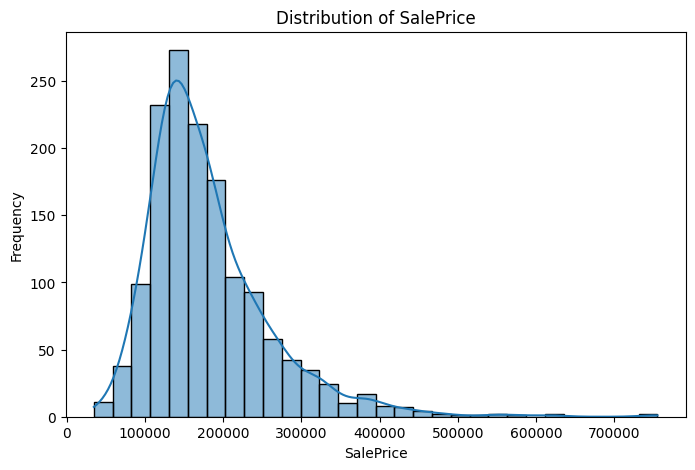

In [3]:
# Data Distirbution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], bins=30, kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

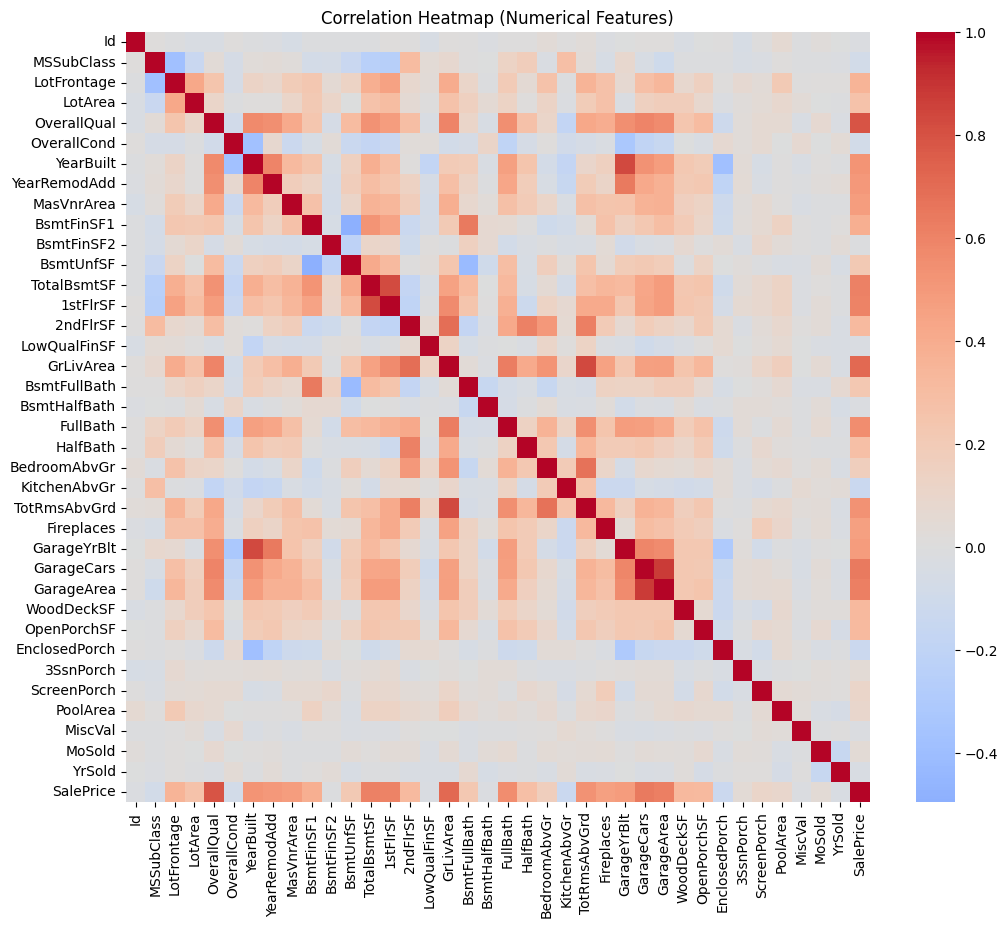

In [4]:
# Correlation Heatmap

plt.figure(figsize=(12,10))

corr = train.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)

plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

The target variable shows a right-skewed distribution, and several numerical features are moderately correlated with the sale price.

## Feature Engineerung

we create a few samole, safe features that usually help:
* TotalSF: total finished are proxy
* HouseAge: age at sale year
* RemodAge: years since remodel at sale
* Bathrooms: full baths + half baths as 0.5
* RoomPerArea: rooms per living area

## Data Cleaning

In [5]:
train['Alley'] = train['Alley'].fillna("NoAlley")
test['Alley'] = test['Alley'].fillna("NoAlley")

In [6]:
(train["KitchenQual"] == "Po").sum()

0

In [7]:
#lotshape
lotshape_map = {
    "IR3": 0,
    "IR2": 1,
    "IR1": 2,
    "Reg": 3
}
train["LotShape"] = train["LotShape"].map(lotshape_map)
test["LotShape"]  = test["LotShape"].map(lotshape_map)

train["LotShape"] = train["LotShape"].fillna(0)
test["LotShape"]  = test["LotShape"].fillna(0)

#BsmtQual
train["BsmtQual"] = train["BsmtQual"].fillna("Missing")
test["BsmtQual"]  = test["BsmtQual"].fillna("Missing")

BsmtQual_map = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1,
    "Missing": 0
}
train["BsmtQual"] = train["BsmtQual"].map(BsmtQual_map)
test["BsmtQual"]  = test["BsmtQual"].map(BsmtQual_map)

#BsmtCond
train["BsmtCond"] = train["BsmtCond"].fillna("Missing")
test["BsmtCond"]  = test["BsmtCond"].fillna("Missing")

BsmtCond_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "Missing": 0}
train["BsmtCond"] = train["BsmtCond"].map(BsmtCond_map)
test["BsmtCond"]  = test["BsmtCond"].map(BsmtCond_map)

#BsmtFinType1
train["BsmtFinType1"] = train["BsmtFinType1"].fillna("Missing")
test["BsmtFinType1"]  = test["BsmtFinType1"].fillna("Missing")

BsmtFinType1_map = {
    "GLQ": 6,
    "ALQ": 5,
    "BLQ": 4,
    "Rec": 3,
    "LwQ": 2,
    "Unf": 1,
    "Missing": 0
}
train["BsmtFinType1"] = train["BsmtFinType1"].map(BsmtFinType1_map)
test["BsmtFinType1"]  = test["BsmtFinType1"].map(BsmtFinType1_map)

#BsmtFinType2
train["BsmtFinType2"] = train["BsmtFinType2"].fillna("Missing")
test["BsmtFinType2"]  = test["BsmtFinType2"].fillna("Missing")

BsmtFinType2_map = {
    "GLQ": 6,
    "ALQ": 5,
    "BLQ": 4,
    "Rec": 3,
    "LwQ": 2,
    "Unf": 1,
    "Missing": 0
}
train["BsmtFinType2"] = train["BsmtFinType2"].map(BsmtFinType2_map)
test["BsmtFinType2"]  = test["BsmtFinType2"].map(BsmtFinType2_map)

#HeatingQC
HeatingQC_map = {
    "Ex": 4,
    "Gd": 3,
    "TA": 2,
    "Fa": 1,
    "Po": 0
}
train["HeatingQC"] = train["HeatingQC"].map(HeatingQC_map).fillna(0)
test["HeatingQC"]  = test["HeatingQC"].map(HeatingQC_map).fillna(0)

#KitchenQual
KitchenQual_map = {
    "Ex": 4,
    "Gd": 3,
    "TA": 2,
    "Fa": 1,
    "Po": 0
}
train["KitchenQual"] = train["KitchenQual"].map(KitchenQual_map).fillna(0)
test["KitchenQual"]  = test["KitchenQual"].map(KitchenQual_map).fillna(0)

#Functional
Functional_map = {
    "Typ": 7,
    "Min1": 6,
    "Min2": 5,
    "Mod": 4,
    "Maj1": 3,
    "Maj2": 2,
    "Sev": 1,
    "Sal": 0
}
train["Functional"] = train["Functional"].map(Functional_map).fillna(0)
test["Functional"]  = test["Functional"].map(Functional_map).fillna(0)

#FireplaceQu
train["FireplaceQu"] = train["FireplaceQu"].fillna("Missing")
test["FireplaceQu"]  = test["FireplaceQu"].fillna("Missing")

FireplaceQu_map = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1,
    "Missing": 0
}
train["FireplaceQu"] = train["FireplaceQu"].map(FireplaceQu_map)
test["FireplaceQu"]  = test["FireplaceQu"].map(FireplaceQu_map)

#GarageFinish
train["GarageFinish"] = train["GarageFinish"].fillna("Missing")
test["GarageFinish"]  = test["GarageFinish"].fillna("Missing")

GarageFinish_map = {
    "Fin": 3,
    "RFn": 2,
    "Unf": 1,
    "Missing": 0
}
train["GarageFinish"] = train["GarageFinish"].map(GarageFinish_map)
test["GarageFinish"]  = test["GarageFinish"].map(GarageFinish_map)

#GarageQual
train["GarageQual"] = train["GarageQual"].fillna("Missing")
test["GarageQual"]  = test["GarageQual"].fillna("Missing")

GarageQual_map = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1,
    "Missing": 0
}
train["GarageQual"] = train["GarageQual"].map(GarageQual_map)
test["GarageQual"]  = test["GarageQual"].map(GarageQual_map)

#GarageCond
train["GarageCond"] = train["GarageCond"].fillna("Missing")
test["GarageCond"]  = test["GarageCond"].fillna("Missing")

GarageCond_map = {
    "Ex": 5,
    "Gd": 4,
    "TA": 3,
    "Fa": 2,
    "Po": 1,
    "Missing": 0
}
train["GarageCond"] = train["GarageCond"].map(GarageCond_map)
test["GarageCond"]  = test["GarageCond"].map(GarageCond_map)

#PavedDrive
train["PavedDrive"] = train["PavedDrive"].fillna("Missing")
test["PavedDrive"]  = test["PavedDrive"].fillna("Missing")

PavedDrive_map = {
    "Y": 3,
    "P": 2,
    "N": 1,
    "Missing": 0}

train["PavedDrive"] = train["PavedDrive"].map(PavedDrive_map)
test["PavedDrive"]  = test["PavedDrive"].map(PavedDrive_map)

#PoolQC
train["PoolQC"] = train["PoolQC"].fillna("Missing")
test["PoolQC"]  = test["PoolQC"].fillna("Missing")

PoolQC_map = {
    "Ex": 4,
    "Gd": 3,
    "TA": 2,
    "Fa": 1,
    "Missing": 0
}
train["PoolQC"] = train["PoolQC"].map(PoolQC_map)
test["PoolQC"]  = test["PoolQC"].map(PoolQC_map)

#Fence
train["Fence"] = train["Fence"].fillna("Missing")
test["Fence"]  = test["Fence"].fillna("Missing")

Fence_map = {
    "GdPrv": 4,
    "MnPrv": 3,
    "GdWo": 2,
    "MnWw": 1,
    "Missing": 0
}

train["Fence"] = train["Fence"].map(Fence_map)
test["Fence"]  = test["Fence"].map(Fence_map)

In [8]:
cols_check = ["LotShape","BsmtQual","BsmtCond","BsmtFinType1","BsmtFinType2",
              "HeatingQC","KitchenQual","Functional","FireplaceQu","GarageFinish",
              "GarageQual","GarageCond","PavedDrive","PoolQC","Fence"]

print("NaNs train:", train[cols_check].isna().sum().sum())
print("NaNs test :", test[cols_check].isna().sum().sum())

NaNs train: 0
NaNs test : 0


## Feature Engineering

In [9]:

train["TotalSF"] = train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]
test["TotalSF"]  = test["TotalBsmtSF"]  + test["1stFlrSF"]  + test["2ndFlrSF"]

train["HouseAge"] = train["YrSold"] - train["YearBuilt"]
test["HouseAge"] = test["YrSold"] - test["YearBuilt"]

train["RemodAge"] = train["YrSold"] - train["YearRemodAdd"]
test["RemodAge"] = test["YrSold"] - test["YearRemodAdd"]

train["Bathrooms"] = train["FullBath"] + 0.5 * train["HalfBath"]
test["Bathrooms"] = test["FullBath"] + 0.5 * test["HalfBath"]

train["RoomsPerArea"] = train["TotRmsAbvGrd"] / train["GrLivArea"]
test["RoomsPerArea"] = test["TotRmsAbvGrd"] / test["GrLivArea"]

In [10]:
# I add a safety step to handle potential infinite values created by feature ratio 
# to enjure model stability
train["RoomsPerArea"] = train["RoomsPerArea"].replace([np.inf, -np.inf], 0)
test["RoomsPerArea"] = test["RoomsPerArea"].replace([np.inf, -np.inf], 0)

In [11]:
print("NaNs in train:", train.isna().sum().sum())
print("NaNs in test:", test.isna().sum().sum())

NaNs in train: 2746
NaNs in test: 2762


In [12]:
# check nmapped_cols = ["LotShape","BsmtQual","BsmtCond","BsmtFinType1","BsmtFinType2",
mapped_cols = [
    "LotShape",
    "BsmtQual",
    "BsmtCond",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    "PoolQC",
    "Fence"
]

for col in mapped_cols:
    print(
        f"{col}: train NaNs = {train[col].isna().sum()} | "
        f"test NaNs = {test[col].isna().sum()}"
    )

LotShape: train NaNs = 0 | test NaNs = 0
BsmtQual: train NaNs = 0 | test NaNs = 0
BsmtCond: train NaNs = 0 | test NaNs = 0
BsmtFinType1: train NaNs = 0 | test NaNs = 0
BsmtFinType2: train NaNs = 0 | test NaNs = 0
HeatingQC: train NaNs = 0 | test NaNs = 0
KitchenQual: train NaNs = 0 | test NaNs = 0
Functional: train NaNs = 0 | test NaNs = 0
FireplaceQu: train NaNs = 0 | test NaNs = 0
GarageFinish: train NaNs = 0 | test NaNs = 0
GarageQual: train NaNs = 0 | test NaNs = 0
GarageCond: train NaNs = 0 | test NaNs = 0
PavedDrive: train NaNs = 0 | test NaNs = 0
PoolQC: train NaNs = 0 | test NaNs = 0
Fence: train NaNs = 0 | test NaNs = 0


## Train_Test_Split

In [13]:
# drop column

X = train.drop('Id', axis=1)
y = X.pop("SalePrice")
id_column = test.pop('Id')


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [14]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))


Numeric: 56
Categorical: 28


# Preprocessing pipeline

handling missing values inside the pipeline:
* Numeric: median imputation + scaling
* Categorical: most frequent imputation one-hot
  

In [15]:
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ]
)

# Model Evaluation

In [16]:
#base line
baseline = Pipeline([
    ('preprocessor', preprocessor),
     ('model', LinearRegression())
])
baseline.fit(X_train, y_train)

baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

In [17]:
#Ridge

from sklearn.linear_model import Ridge

ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("var", VarianceThreshold(threshold=0.0)),
    ("model", Ridge(alpha=1.0))
])

ridge_scores = cross_val_score(
    ridge,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("Ridge CV RMSE:", ridge_scores.mean())

Ridge CV RMSE: -35237.222247397505


In [18]:
# LassoCV

lassoCV = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LassoCV(alphas=np.logspace(-4, 1, 30), cv=5, max_iter=50000))
])
lassoCV_scores = cross_val_score(
    lassoCV,  
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)
print("LassoCV CV RMSE:", -lassoCV_scores.mean())

LassoCV CV RMSE: 38415.02051015907


In [19]:
# Gardient Boosting Regressor

gbr = Pipeline([
    ("preprocessor", preprocessor),
    ("var", VarianceThreshold()),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [900],
    "model__learning_rate": [0.03],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8],
    "model__random_state": [42]
}

gbr_grid = GridSearchCV(
    gbr,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gbr_grid.fit(X_train, y_train)

print("GBR CV RMSE:", -gbr_grid.best_score_)
print("Best params:", gbr_grid.best_params_)
best_pipe = gbr_grid.best_estimator_

GBR CV RMSE: 27775.739582143367
Best params: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 900, 'model__random_state': 42, 'model__subsample': 0.8}


In [20]:
# RandomForestRegressor

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("var", VarianceThreshold()),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("Random Forest CV RMSE:", -rf_scores.mean())

Random Forest CV RMSE: 29464.738960747076


In [21]:
# score

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Random Forest Test R2: {test_r2: 3f}")
print(f"Random Forest Test RMSE:, {test_rmse: 3f}")

Random Forest Test R2:  0.887100
Random Forest Test RMSE:,  29427.555324


In [22]:
# select the best Model:

print("Baseline CV RMSE:", -baseline_scores.mean())
print("Ridge CV RMSE:", -ridge_scores.mean())
print("Lasso CV RMSE:", -lassoCV_scores.mean())
print("GBR CV RMSE:", -gbr_grid.best_score_)
print("RF CV RMSE:", -rf_scores.mean())

Baseline CV RMSE: 27563624742741.02
Ridge CV RMSE: 35237.222247397505
Lasso CV RMSE: 38415.02051015907
GBR CV RMSE: 27775.739582143367
RF CV RMSE: 29464.738960747076


In [23]:
best_pipe = gbr_grid.best_estimator_
best_pipe.fit(X, y)

test_pred = best_pipe.predict(test)

submission = pd.DataFrame({
    "Id": id_column,
    "SalePrice": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

,Id,SalePrice
0,1461,120895.027139
1,1462,166933.324439
2,1463,188063.702054
3,1464,194137.872972
4,1465,183603.212506


## Conclusion

Gradient Boosting achieved the best cross-validated performance.
The project demonstrates an end-to-end regression workflow,
from data preparation to model evaluation and submission.

Future improvements could include:
- Hyperparameter tuning
- Feature importance analysis
- Model interpretability